In [1]:
import numpy as np
import matplotlib.pyplot as plt

from constants import *
from self_consistency_k import build_bdg_hamiltonian, bdg_sc_full_k

In [2]:
T_arr = np.linspace(0.001, 0.15, 100)

Fuu_px_arr = np.zeros_like(T_arr, dtype=np.complex128)
Fuu_py_arr = np.zeros_like(T_arr, dtype=np.complex128)

Fdd_px_arr = np.zeros_like(T_arr, dtype=np.complex128)
Fdd_py_arr = np.zeros_like(T_arr, dtype=np.complex128)

t = 1
mu = 1.5

Nx,Ny = 30, 30

V_prime = 1.5 * t

atol = 1e-6
rtol = 1e-3
maxiter = 1000

In [3]:
for i, T in enumerate(T_arr):
    out = bdg_sc_full_k(
        t, mu, Nx, Ny, V_prime=V_prime,
        temperature=T, maxiter=maxiter,
        verbose=False, atol=atol,rtol=rtol,
        Fuu_init=np.array([0.1, -0.1, 0.1j, -0.1j], dtype=np.complex128),
        Fdd_init=np.array([0.1, -0.1, 0.1j, -0.1j], dtype=np.complex128)
    )

    Fuu_px_arr[i] = out.Fuu_px
    Fuu_py_arr[i] = out.Fuu_py

    Fdd_px_arr[i] = out.Fdd_px
    Fdd_py_arr[i] = out.Fdd_py

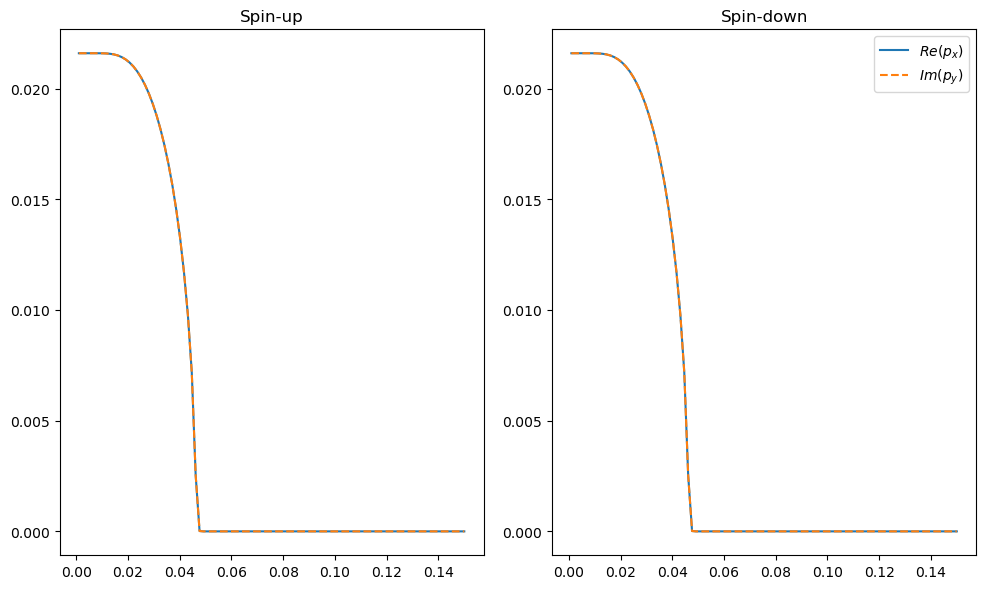

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

axs[0].set_title("Spin-up")
axs[0].plot(T_arr, np.real(Fuu_px_arr), label=r"$Re(p_x)$")
axs[0].plot(T_arr, np.imag(Fuu_py_arr), '--', label=r"$Im(p_y)$")

axs[1].set_title("Spin-down")
axs[1].plot(T_arr, np.real(Fdd_px_arr), label=r"$Re(p_x)$")
axs[1].plot(T_arr, np.imag(Fdd_py_arr), '--', label=r"$Im(p_y)$")

plt.legend()
plt.tight_layout()
plt.show()